# Introduction to Image Processing
## Assignment 2

**Deadline: 9th June EOD**

---

### Instructions
- Attempt all questions.
- Write clean and readable code.
- Explain theoretical answers in your own words in the text cell in notebook (.ipynb), not as comments in code cells.
- Use comments wherever necessary.
- You may use NumPy and Pillow library.


# Question 1: Understanding Digital Images (Easy)

A grayscale image is represented by:

|20|40|60|
|--|--|--|
|80|100|120|
|140|160|180|


## Part A (Theory)

1. What is a pixel?
2. What does the value 0 represent in a grayscale image?
3. What does the value 255 represent?
4. How many pixels are present in the image above?


1 A pixel is a picture element Any image can be broken down into pixels A pixel stores intensity or colour of a small part of an image

2 zero represents black colour

3 255 represents white colour

4 the image has 9 pixels (20 40 60 80 100 120 140 160 180)

## Part B (Coding)

Write a Python program that:

1. Stores the matrix using NumPy.
2. Prints image dimensions.
3. Finds:
   - Minimum pixel value
   - Maximum pixel value
   - Average pixel value


In [ ]:
import numpy
arr = numpy.array([[20,40,60],[80,100,120],[140,160,180]])
print("Dimensions of the image is (3,3)")

min =max = arr[0][0]
sum =0
for i in range(3) :
  for j in range (3) :
    if arr[i][j] >= max :
      max = arr[i][j]
    if arr[i][j] <= min :
      min = arr[i][j]
    sum+=arr[i][j]
avg=sum/(9.0)
print ("Maximum pixel value is ", max )
print ("Minimum pixel value is ", min)
print("Average pixel value is ", avg)




Dimensions of the image is (3,3)
Maximum pixel value is  180
Minimum pixel value is  20
Average pixel value is  100.0


# Question 2: RGB Image Analysis (Medium)

Consider the RGB pixel values:

```text
(255,0,0)
(0,255,0)
(0,0,255)
(255,255,0)
(255,255,255)
```


## Part A (Theory)

1. What does RGB stand for?
2. Why are three channels used?
3. What color is produced by:
   - (255,255,0)
   - (255,0,255)
   - (0,255,255)
4. Explain why RGB is suitable for digital displays.


1 RGB stands for Red Green Blue

2 These channels are used as human eyes contains receptors sensitive to R,G,B wavelengths and they can be combined to make almost any visible colour

3 (255 255 0 ) is Yellow , (255 0 255) is Magenta and (0 255 255) is Cyan

4 it is because these three can be combined in different ratios to make (256^3) different colours

## Part B (Coding)

Create a NumPy array containing at least 10 RGB pixels.

Write a program that:

1. Calculates average Red value.
2. Calculates average Green value.
3. Calculates average Blue value.
4. Finds the brightest pixel using:

`Brightness = (R + G + B) / 3`


In [ ]:
import numpy
arr = numpy.array([
    [122,67,76],
    [1,65,135],
    [233,233,2],
    [245,90,45],
    [65,56,45],
    [1,2,3],
    [200,13,199],
    [234,145,123],
    [75,255,255],
    [123,54,67]
  ])

r=g=b=0
for i in range(10) :
  r+=arr[i,0]
  g+=arr[i,1]
  b+=arr[i,2]

r=r/(10.0)
g=g/(10.0)
b=b/(10.0)

print("Average Red value is ", r)
print("Average Green value is ",g)
print("Average Blue value is ",b)

brightest=0
s=0
pixel=-1
for i in range (10) :
  for j in range (3) :
    s+=arr[i,j]
  if(s/(3.0) >= brightest) :
    brightest=s/(3.0)
    pixel=i
  s=0

print("Brightest pixel is ")
for i in range (3) :
  print(arr[pixel,i], end = " ")




Average Red value is  129.9
Average Green value is  98.0
Average Blue value is  95.0
Brightest pixel is 
75 255 255 

## Part A (Theory)

1. What is cropping?
2. What is ROI (Region of Interest) and its use case?
3. What is aspect ratio, and why should it be preserved?


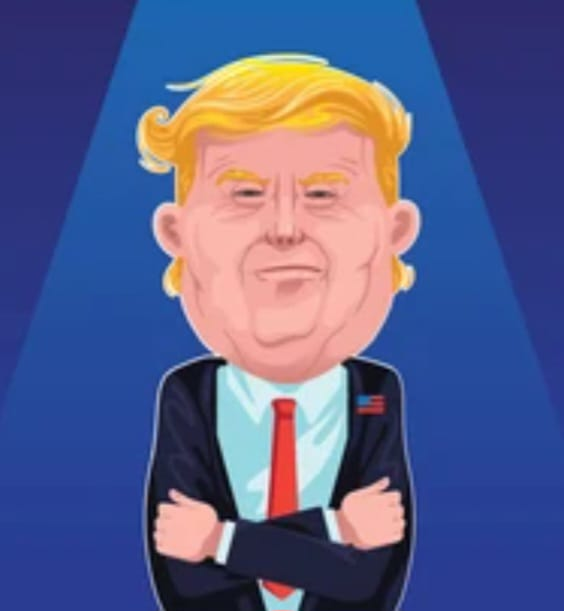

1 Cropping means extracting a specific region of an image

2 A area selected after cropping unnecessary background is called ROI It reduces computations and focuses processing It is used in ID detection devices

3 Aspect ratio is width/height It should be preserved to prevent distortion and maintain image quality

## Part B (Coding)

Write a program that:

1. Loads an image.
2. Displays original dimensions.
3. Crops the center region.
4. Resizes the cropped image to:
   - 300 × 300
   - 600 × 600
5. Save all generated images.


Original dimensions are  564 X 611


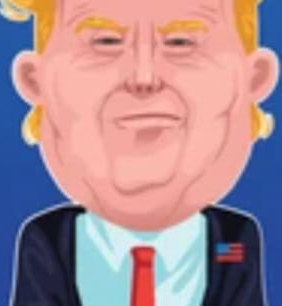

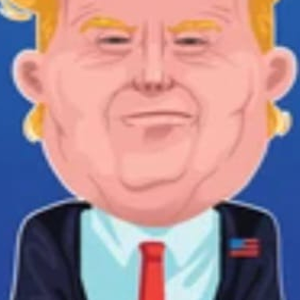

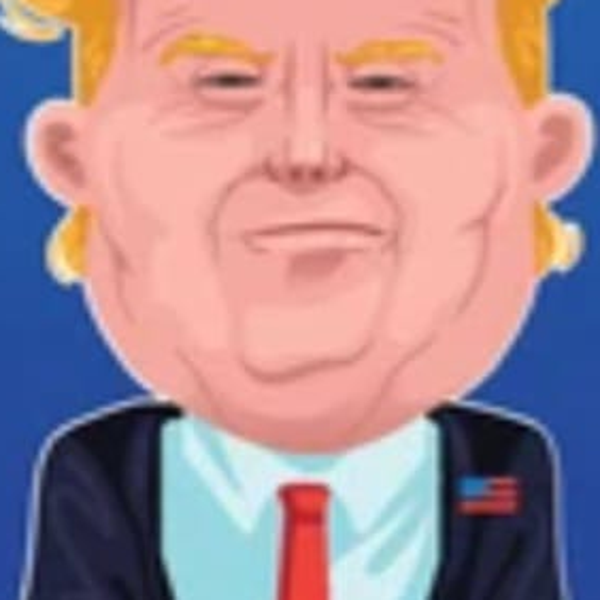

In [ ]:
from PIL import Image
image = Image.open("image.jpeg")
w,h = image.size
print("Original dimensions are ",w,"X", h)
l=w//4
top=h//4
r=3*w//4
bot=3*h//4

cropped=image.crop((l,top,r,bot))

i1=cropped.resize((300,300))
i2=cropped.resize((600,600))

cropped.save("Cropped.jpg")
i1.save("i1.jpg")
i2.save("i2.jpg")

display(cropped)
display(i1)
display(i2)

## Part C (Analysis)

Compare the original image and resized images.

Discuss:
- Quality changes
- Distortion (if any)
- Aspect ratio effects


The quality of cropped ,i1 and i2 have decreased as compared to the original image as the image has been zoomed

Distortion :There is a little horizontal compression in i1 while i2 has significant horizontal stretching

The aspect ratio of image and cropped is 1:1 both are square images While i1 and i2 appear as a slightly tall and slightly wide rectangle

# Question 4: Interpolation Investigation (Hard)

Different interpolation techniques produce different results.


## Part A (Theory)

Research and explain:

1. Nearest Neighbor Interpolation
2. Bilinear Interpolation
3. Bicubic Interpolation
4. Lanczos Interpolation

For each method discuss:
- Working principle
- Advantages
- Disadvantages
- Suitable applications


1 Nearest Neihbour Interpolation

Principle : It finds the position of the target pixel in the original image grid and and assigns it the same colour value as the pixel next to it

Advantages : It is fast , preserves sharp edges and good for pixel art

Disadvantages : downscalling can lead to loss of data

Applications : it is used in pixel art


2 Bilinear Interpolation

Principle : It performs linear interpolation on the 4 closest neighbours of the target pixel based on weighted distances

Advantage : It reduces the blocky artifacts visible in nearest neighbour interpolation

Disadvantages : As it averages the values , sharp edges and fine details becomes blured

Applications : It is used in photo resizing


3 Bicubic Interpolation

Principle : it interpolates a 4X4 pixel neighbourhood It uses weighted non linear curves to blend the data due to which one can account for rate of change in pixel intensity

Advantages : it gives better quality , sommth transitions and reduced artifacts

Disadvantages : it requires more time and processing power

Applications : it is used in photo editing and digital photography


4 Lanczos Interpolation

Principle : it uses 16 to 36 neighbours it uses sinc(x)= sin(pi x)/(pi x) and L(x)=sinc(x)sinc(x/a)
which truncates the sampling window and calculates the missing values

Advantages : it gives excellent quality, sharp details and minimal aliasing

Disadvantages : It is the slowest and the most resource intensive algorithm

Applications : It is used in high end video encoding


## Part B (Coding)

Using the same image:

1. Resize the image to 100x100.
2. Resize it back to 800x800 using:
   - Nearest Neighbor
   - Bilinear
   - Bicubic
   - Lanczos
3. Save all outputs.


array([[[109,  42,  45],
        [109,  42,  45],
        [109,  42,  45],
        ...,
        [109,  42,  45],
        [109,  42,  45],
        [109,  42,  45]],

       [[109,  42,  45],
        [109,  42,  45],
        [109,  42,  45],
        ...,
        [109,  42,  45],
        [109,  42,  45],
        [109,  42,  45]],

       [[109,  42,  46],
        [109,  42,  46],
        [109,  42,  46],
        ...,
        [109,  42,  46],
        [109,  42,  46],
        [109,  42,  46]],

       ...,

       [[146,  60,  42],
        [146,  60,  42],
        [146,  60,  42],
        ...,
        [146,  60,  42],
        [146,  60,  42],
        [146,  60,  42]],

       [[146,  60,  42],
        [146,  60,  42],
        [146,  60,  42],
        ...,
        [146,  60,  42],
        [146,  60,  42],
        [146,  60,  42]],

       [[146,  60,  42],
        [146,  60,  42],
        [146,  60,  42],
        ...,
        [146,  60,  42],
        [146,  60,  42],
        [146,  60,  42]]], dtype=uint8)
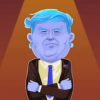

array([[[109,  42,  45],
        [109,  42,  45],
        [109,  42,  45],
        ...,
        [109,  42,  45],
        [109,  42,  45],
        [109,  42,  45]],

       [[109,  42,  45],
        [109,  42,  45],
        [109,  42,  45],
        ...,
        [109,  42,  45],
        [109,  42,  45],
        [109,  42,  45]],

       [[109,  42,  45],
        [109,  42,  45],
        [109,  42,  45],
        ...,
        [109,  42,  45],
        [109,  42,  45],
        [109,  42,  45]],

       ...,

       [[146,  60,  42],
        [146,  60,  42],
        [146,  60,  42],
        ...,
        [146,  60,  42],
        [146,  60,  42],
        [146,  60,  42]],

       [[146,  60,  42],
        [146,  60,  42],
        [146,  60,  42],
        ...,
        [146,  60,  42],
        [146,  60,  42],
        [146,  60,  42]],

       [[146,  60,  42],
        [146,  60,  42],
        [146,  60,  42],
        ...,
        [146,  60,  42],
        [146,  60,  42],
        [146,  60,  42]]], dtype=uint8)
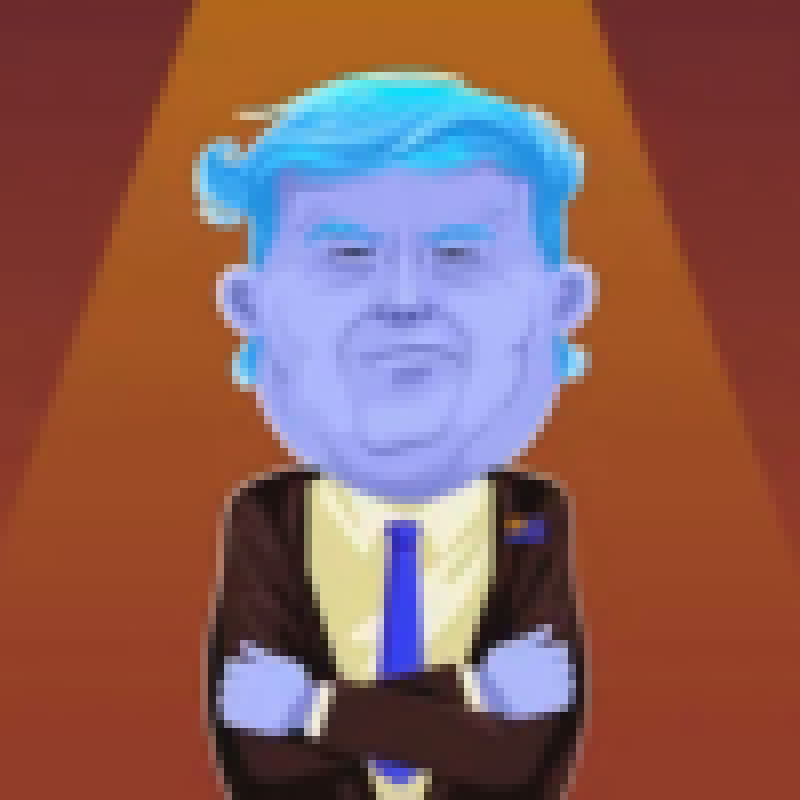

array([[[109,  42,  45],
        [109,  42,  45],
        [109,  42,  45],
        ...,
        [109,  42,  45],
        [109,  42,  45],
        [109,  42,  45]],

       [[109,  42,  45],
        [109,  42,  45],
        [109,  42,  45],
        ...,
        [109,  42,  45],
        [109,  42,  45],
        [109,  42,  45]],

       [[109,  42,  45],
        [109,  42,  45],
        [109,  42,  45],
        ...,
        [109,  42,  45],
        [109,  42,  45],
        [109,  42,  45]],

       ...,

       [[146,  60,  42],
        [146,  60,  42],
        [146,  60,  42],
        ...,
        [146,  60,  42],
        [146,  60,  42],
        [146,  60,  42]],

       [[146,  60,  42],
        [146,  60,  42],
        [146,  60,  42],
        ...,
        [146,  60,  42],
        [146,  60,  42],
        [146,  60,  42]],

       [[146,  60,  42],
        [146,  60,  42],
        [146,  60,  42],
        ...,
        [146,  60,  42],
        [146,  60,  42],
        [146,  60,  42]]], dtype=uint8)
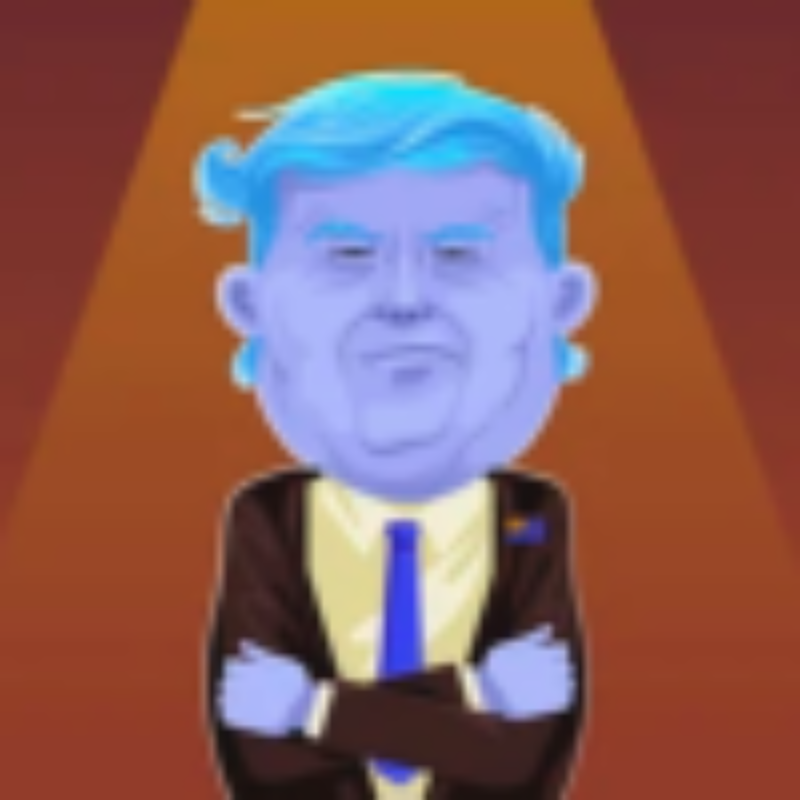

array([[[109,  42,  45],
        [109,  42,  45],
        [109,  42,  45],
        ...,
        [109,  42,  45],
        [109,  42,  45],
        [109,  42,  45]],

       [[109,  42,  45],
        [109,  42,  45],
        [109,  42,  45],
        ...,
        [109,  42,  45],
        [109,  42,  45],
        [109,  42,  45]],

       [[109,  42,  45],
        [109,  42,  45],
        [109,  42,  45],
        ...,
        [109,  42,  45],
        [109,  42,  45],
        [109,  42,  45]],

       ...,

       [[146,  60,  42],
        [146,  60,  42],
        [146,  60,  42],
        ...,
        [146,  60,  42],
        [146,  60,  42],
        [146,  60,  42]],

       [[146,  60,  42],
        [146,  60,  42],
        [146,  60,  42],
        ...,
        [146,  60,  42],
        [146,  60,  42],
        [146,  60,  42]],

       [[146,  60,  42],
        [146,  60,  42],
        [146,  60,  42],
        ...,
        [146,  60,  42],
        [146,  60,  42],
        [146,  60,  42]]], dtype=uint8)
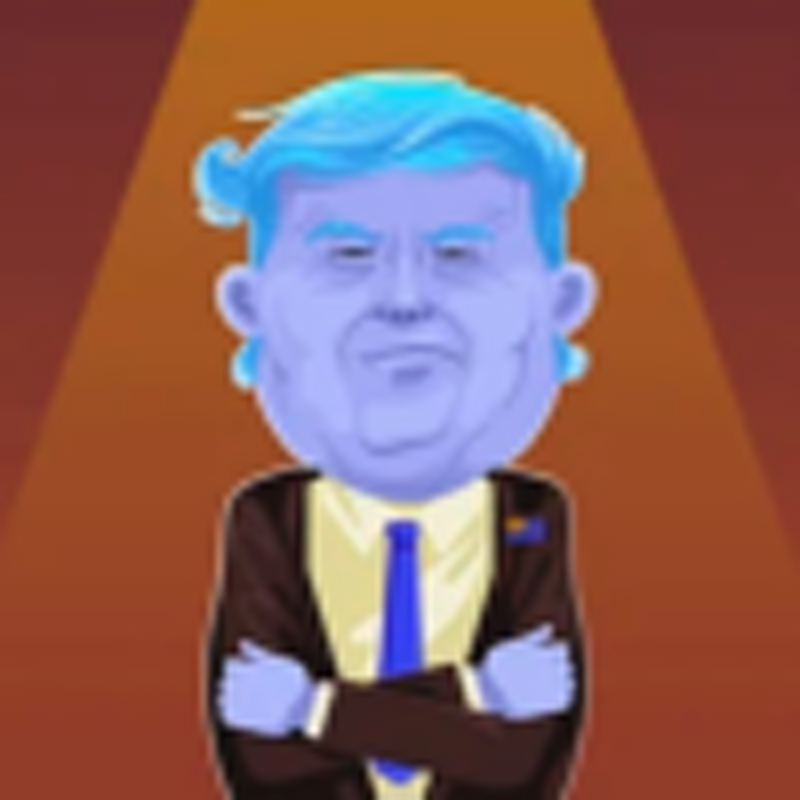

array([[[109,  42,  45],
        [109,  42,  45],
        [109,  42,  45],
        ...,
        [109,  42,  45],
        [109,  42,  45],
        [109,  42,  45]],

       [[109,  42,  45],
        [109,  42,  45],
        [109,  42,  45],
        ...,
        [109,  42,  45],
        [109,  42,  45],
        [109,  42,  45]],

       [[109,  42,  45],
        [109,  42,  45],
        [109,  42,  45],
        ...,
        [109,  42,  45],
        [109,  42,  45],
        [109,  42,  45]],

       ...,

       [[146,  60,  42],
        [146,  60,  42],
        [146,  60,  42],
        ...,
        [146,  60,  42],
        [146,  60,  42],
        [146,  60,  42]],

       [[146,  60,  42],
        [146,  60,  42],
        [146,  60,  42],
        ...,
        [146,  60,  42],
        [146,  60,  42],
        [146,  60,  42]],

       [[146,  60,  42],
        [146,  60,  42],
        [146,  60,  42],
        ...,
        [146,  60,  42],
        [146,  60,  42],
        [146,  60,  42]]], dtype=uint8)
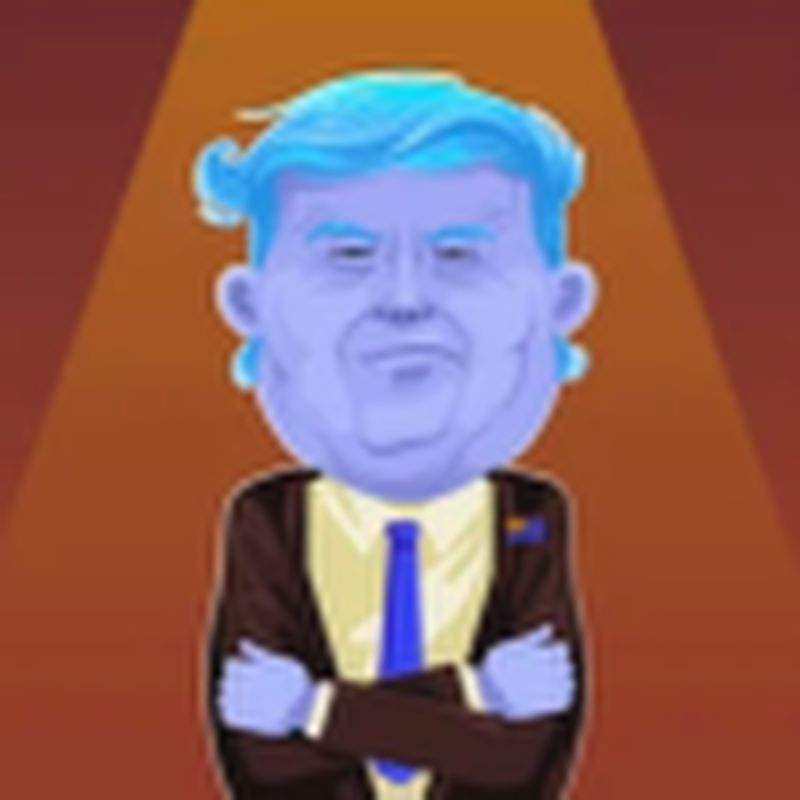

In [ ]:
import cv2

image = cv2.imread('image.jpeg')

shrunk_image = cv2.resize(image, (100, 100), interpolation=cv2.INTER_AREA)
cv2.imwrite('resized_100x100.jpeg', shrunk_image)
display(shrunk_image)

target_size = (800, 800)

# A. Nearest Neighbor
nearest_output = cv2.resize(shrunk_image, target_size, interpolation=cv2.INTER_NEAREST)
cv2.imwrite('nearest.jpeg', nearest_output)
display(nearest_output)


# B. Bilinear
bilinear_output = cv2.resize(shrunk_image, target_size, interpolation=cv2.INTER_LINEAR)
cv2.imwrite('bilinear.jpeg', bilinear_output)
display(bilinear_output)


# C. Bicubic
bicubic_output = cv2.resize(shrunk_image, target_size, interpolation=cv2.INTER_CUBIC)
cv2.imwrite('bicubic.jpeg', bicubic_output)
display(bicubic_output)

# D. Lanczos
lanczos_output = cv2.resize(shrunk_image, target_size, interpolation=cv2.INTER_LANCZOS4)
cv2.imwrite('lanczos.jpeg', lanczos_output)
display(lanczos_output)


## Part C (Analysis)

Compare all outputs and answer:

1. Which method preserved the most detail?
2. Which method appeared blurriest?
3. Which method is best for pixel art?
4. Which method would you choose for CubeCanvas and why?


1 Lanczos Interpolation preserves the most details
2 Bilinear Interpolation appeared blurriest
3 Nearest Neighbour Interpolation is best for pixel art
4 Lanczos Interpolation as it preserves the most details and gives a good quality image

# Question 5 (Mini Project - 50 Marks)

# Image Processing Explorer

Create a Python application that demonstrates all major concepts learned in this module.

Your application should:

1. Load an image.

   *(Spongebob image pl ;-))*

2. Display image dimensions.
3. Display aspect ratio.
4. Resize the cropped image to user-specified dimensions.
5. Generate outputs using:
   - Nearest Neighbor
   - Bilinear
   - Bicubic
   - Lanczos
6. Display pixel values at user-selected coordinates.
7. Compute:
   - Average Red value
   - Average Green value
   - Average Blue value
8. Save all generated images automatically.

## Bonus Features (Optional)

Implement any two:

1. Brightness adjustment.
2. Contrast adjustment.
3. Grayscale conversion.
4. Image rotation.
5. Histogram visualization.


In [ ]:
from PIL import Image
import numpy as np

img = Image.open("spongebob.jpeg")

w, h = img.size
print(f"Dimensions: {w} x {h}")

ar = w / h
print(f"Aspect Ratio: {ar:.2f}")

img.show()

left = w // 4
top = h // 4
right = 3 * w // 4
bot = 3 * h // 4

cropped_img = img.crop((left, top, right, bot))
cropped_img.save("cropped_image.jpeg")

neww = int(input("Enter new width: "))
newh = int(input("Enter new height: "))

nearest = cropped_img.resize((neww, newh), Image.NEAREST)
nearest.save("nearest_neighbor.jpeg")

bilinear = cropped_img.resize((neww, newh), Image.BILINEAR)
bilinear.save("bilinear.jpeg")

bicubic = cropped_img.resize((neww, newh), Image.BICUBIC)
bicubic.save("bicubic.jpeg")

lanczos = cropped_img.resize((neww, newh), Image.LANCZOS)
lanczos.save("lanczos.jpeg")

x = int(input("Enter x coordinate: "))
y = int(input("Enter y coordinate: "))

pixel = img.getpixel((x, y))
print(f"Pixel value at ({x}, {y}) = {pixel}")

img_array = np.array(img)

red = np.mean(img_array[:, :, 0])
green = np.mean(img_array[:, :, 1])
blue = np.mean(img_array[:, :, 2])

print(f"Average Red Value: {red:.2f}")
print(f"Average Green Value: {green:.2f}")
print(f"Average Blue Value: {blue:.2f}")


Dimensions: 491 x 379
Aspect Ratio: 1.30
Enter new width: 300
Enter new height: 300
Enter x coordinate: 12
Enter y coordinate: 12
Pixel value at (12, 12) = (24, 131, 151)
Average Red Value: 51.94
Average Green Value: 138.32
Average Blue Value: 141.42


## Project Notes / Explanation (if any)

Write your explanation here.